In [ ]:
# --- LIBRARIES ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.io import savemat

# ------------------------------------------------------------------------------

In [ ]:
# ---ALL SECTIONS DATA IMPORT ---

# Import data
DDQNroute1 = np.load('DDQNpath1.npz')
DDQNroute2 = np.load('DDQNpath2.npz')
DDQNroute3 = np.load('DDQNpath3.npz')
DDQNroute4 = np.load('DDQNpath4.npz')
DDQNroute5 = np.load('DDQNpath5.npz')
DDQNroute6 = np.load('DDQNpath6.npz')
DDQNroute7 = np.load('DDQNpath7.npz')
DDQNroute8 = np.load('DDQNpath8.npz')
DDQNroute9 = np.load('DDQNpath9.npz')
DDQNroute10 = np.load('DDQNpath10.npz')

OTHERroute1 = np.load('OTHERpath1.npz')
OTHERroute2 = np.load('OTHERpath2.npz')
OTHERroute3 = np.load('OTHERpath3.npz')
OTHERroute4 = np.load('OTHERpath4.npz')
OTHERroute5 = np.load('OTHERpath5.npz')
OTHERroute6 = np.load('OTHERpath6.npz')
OTHERroute7 = np.load('OTHERpath7.npz')
OTHERroute8 = np.load('OTHERpath8.npz')
OTHERroute9 = np.load('OTHERpath9.npz')
OTHERroute10 = np.load('OTHERpath10.npz')

# Concatenate DDQN data
DDQNroute = np.vstack((DDQNroute1['route_DDPG'],
                       DDQNroute2['route_DDPG'],
                       DDQNroute3['route_DDPG'],
                       DDQNroute4['route_DDPG'],
                       DDQNroute5['route_DDPG'],
                       DDQNroute6['route_DDPG'],
                       DDQNroute7['route_DDPG'],
                       DDQNroute8['route_DDPG'],
                       DDQNroute9['route_DDPG'],
                       DDQNroute10['route_DDPG']))

# Concatenate GNN data
GNNroute = np.vstack((OTHERroute1['route_GNN'],
                      OTHERroute2['route_GNN'],
                      OTHERroute3['route_GNN'],
                      OTHERroute4['route_GNN'],
                      OTHERroute5['route_GNN'],
                      OTHERroute6['route_GNN'],
                      OTHERroute7['route_GNN'],
                      OTHERroute8['route_GNN'],
                      OTHERroute9['route_GNN'],
                      OTHERroute10['route_GNN']))

# Concatenate OR-Tools data
ORToolsroute = np.vstack((OTHERroute1['route_ORTools'],
                          OTHERroute2['route_ORTools'],
                          OTHERroute3['route_ORTools'],
                          OTHERroute4['route_ORTools'],
                          OTHERroute5['route_ORTools'],
                          OTHERroute6['route_ORTools'],
                          OTHERroute7['route_ORTools'],
                          OTHERroute8['route_ORTools'],
                          OTHERroute9['route_ORTools'],
                          OTHERroute10['route_ORTools']))

# Concatenate Christofides data
Christofidesroute = np.vstack((OTHERroute1['route_Christofides'],
                               OTHERroute2['route_Christofides'],
                               OTHERroute3['route_Christofides'],
                               OTHERroute4['route_Christofides'],
                               OTHERroute5['route_Christofides'],
                               OTHERroute6['route_Christofides'],
                               OTHERroute7['route_Christofides'],
                               OTHERroute8['route_Christofides'],
                               OTHERroute9['route_Christofides'],
                               OTHERroute10['route_Christofides']))

# ------------------------------------------------------------------------------

In [ ]:
# --- FUNCTION TO DIVIDE PLANE IN SECTIONS ---

def split_points_into_grid(points, c, r):

    points = np.asarray(points)
    x = points[:, 0]
    y = points[:, 1]

    # Bounds
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    # Avoid division by zero
    x_range = x_max - x_min if x_max > x_min else 1
    y_range = y_max - y_min if y_max > y_min else 1

    # Compute indices
    col_idx = ((x - x_min) / x_range * c).astype(int)
    row_idx = ((y - y_min) / y_range * r).astype(int)

    # Fix edge case where value == max
    col_idx = np.clip(col_idx, 0, c - 1)
    row_idx = np.clip(row_idx, 0, r - 1)

    # Create grid (list of lists)
    grid = [[[] for _ in range(c)] for _ in range(r)]

    # Assign points
    for i in range(len(points)):
        grid[row_idx[i]][col_idx[i]].append(points[i])

    # Convert lists to numpy arrays
    for i in range(r):
        for j in range(c):
            grid[i][j] = np.array(grid[i][j])

    return grid

# ------------------------------------------------------------------------------

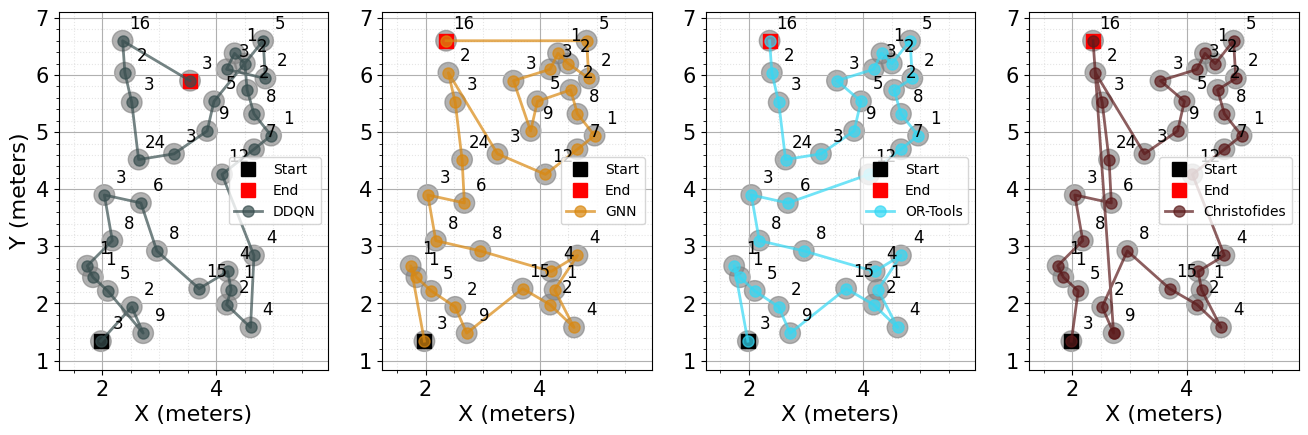

In [ ]:
# --- ROUTE RESULT PER SECTION ---

grid = split_points_into_grid(coords, c=5, r=2)

# Limits for this section
fruit_clusters_ma = grid[0][0][:, 0:3]
real_width_m = [min(fruit_clusters_ma[:, 0]), max(fruit_clusters_ma[:, 0])]
real_height_m = [min(fruit_clusters_ma[:, 1]), max(fruit_clusters_ma[:, 1])]


# Initialize figure
fig, (axb, axc, axd, axe) = plt.subplots(1, 4, figsize=(16, 14))


# --- DDQN Plot

axb.set_xlim(real_width_m[0] - 0.5, real_width_m[1] + 1)
axb.set_ylim(real_height_m[0] - 0.5, real_height_m[1] + 0.5)
axb.set_aspect('equal', adjustable='box')
axb.set_xlabel("X (meters)", fontsize=16)
axb.set_ylabel("Y (meters)", fontsize=16)

# Draw original fruit clusters
all_fruit_coords = [(f[0], f[1], f[2]) for f in fruit_clusters_ma]

for i, (fx, fy, fw) in enumerate(all_fruit_coords):
    circle = plt.Circle((fx, fy), 0.18, color='gray', alpha=0.6)
    axb.add_patch(circle)
    axb.text(fx+0.3, fy+0.3, int(fw+1), color='black', ha='center', va='center', fontsize=12)

# Draw start position
axb.plot(fruit_clusters_ma[1][0], fruit_clusters_ma[1][1], 'ks', markersize=10, label='Start') # Black Square for Start
axb.plot(fruit_clusters_ma[26][0], fruit_clusters_ma[26][1], 'rs', markersize=10, label='End') # Black Square for Start

# Draw the path
route_coords = DDQNroute1['route_DDPG']
path_x = route_coords[:, 0]
path_y = route_coords[:, 1]
axb.plot(path_x, path_y, '-o', alpha=0.7, markersize=8, linewidth=2, label='DDQN', color='#384e4f')
axb.legend()
axb.grid(True)
axb.minorticks_on()
axb.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
axb.tick_params(axis='both', labelsize=15)


# --- GNN Plot

axc.set_xlim(real_width_m[0] -0.5, real_width_m[1] + 1)
axc.set_ylim(real_height_m[0] -0.5, real_height_m[1] + 0.5)
axc.set_aspect('equal', adjustable='box')
axc.set_xlabel("X (meters)", fontsize=16)

# Draw original fruit clusters
all_fruit_coords = [(f[0], f[1], f[2]) for f in fruit_clusters_ma]

for i, (fx, fy, fw) in enumerate(all_fruit_coords):
    circle = plt.Circle((fx, fy), 0.18, color='gray', alpha=0.6)
    axc.add_patch(circle)
    axc.text(fx+0.3, fy+0.3, int(fw+1), color='black', ha='center', va='center', fontsize=12)

# Draw start position
axc.plot(fruit_clusters_ma[1][0], fruit_clusters_ma[1][1], 'ks', markersize=10, label='Start') # Black Square for Start
axc.plot(fruit_clusters_ma[31][0], fruit_clusters_ma[31][1], 'rs', markersize=10, label='End') # Black Square for Start

# Draw the path
route_coords = OTHERroute1['route_GNN']
path_x = route_coords[:, 0]
path_y = route_coords[:, 1]
axc.plot(path_x, path_y, '-o', alpha=0.7, markersize=8, linewidth=2, label='GNN', color='#d98810')
axc.legend()
axc.grid(True)
axc.minorticks_on()
axc.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
axc.tick_params(axis='both', labelsize=15)


# --- OR-Tools Plot

axd.set_xlim(real_width_m[0] -0.5, real_width_m[1] + 1)
axd.set_ylim(real_height_m[0] -0.5, real_height_m[1] + 0.5)
axd.set_aspect('equal', adjustable='box')
axd.set_xlabel("X (meters)", fontsize=16)

# Draw original fruit clusters
all_fruit_coords = [(f[0], f[1], f[2]) for f in fruit_clusters_ma]

for i, (fx, fy, fw) in enumerate(all_fruit_coords):
    circle = plt.Circle((fx, fy), 0.18, color='gray', alpha=0.6)
    axd.add_patch(circle)
    axd.text(fx+0.3, fy+0.3, int(fw+1), color='black', ha='center', va='center', fontsize=12)

# Draw start position
axd.plot(fruit_clusters_ma[1][0], fruit_clusters_ma[1][1], 'ks', markersize=10, label='Start') # Black Square for Start
axd.plot(fruit_clusters_ma[31][0], fruit_clusters_ma[31][1], 'rs', markersize=10, label='End') # Black Square for Start

# Draw the path
route_coords = OTHERroute1['route_ORTools']
path_x = route_coords[:, 0]
path_y = route_coords[:, 1]
axd.plot(path_x, path_y, '-o', alpha=0.7, markersize=8, linewidth=2, label='OR-Tools', color='#34d8f4')
axd.legend()
axd.grid(True)
axd.minorticks_on()
axd.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
axd.tick_params(axis='both', labelsize=15)


# --- Christofides Plot

axe.set_xlim(real_width_m[0] -0.5, real_width_m[1] + 1)
axe.set_ylim(real_height_m[0] -0.5, real_height_m[1] + 0.5)
axe.set_aspect('equal', adjustable='box')
axe.set_xlabel("X (meters)", fontsize=16)

# Draw original fruit clusters
all_fruit_coords = [(f[0], f[1], f[2]) for f in fruit_clusters_ma]

for i, (fx, fy, fw) in enumerate(all_fruit_coords):
    circle = plt.Circle((fx, fy), 0.18, color='gray', alpha=0.6)
    axe.add_patch(circle)
    axe.text(fx+0.3, fy+0.3, int(fw+1), color='black', ha='center', va='center', fontsize=12)

# Draw start position
axe.plot(fruit_clusters_ma[1][0], fruit_clusters_ma[1][1], 'ks', markersize=10, label='Start') # Black Square for Start
axe.plot(fruit_clusters_ma[31][0], fruit_clusters_ma[31][1], 'rs', markersize=10, label='End') # Black Square for Start

# Draw the path
route_coords = OTHERroute1['route_Christofides']
path_x = route_coords[:, 0]
path_y = route_coords[:, 1]
axe.plot(path_x, path_y, '-o', alpha=0.7, markersize=8, linewidth=2, label='Christofides', color='#5C1A1B')
axe.legend()
axe.grid(True)
axe.minorticks_on()
axe.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.2)
axe.tick_params(axis='both', labelsize=15)

plt.savefig("route_section.svg", bbox_inches='tight') # For saving
plt.grid(True)
plt.show()

# ------------------------------------------------------------------------------